In [2]:
# MODEL TRAIN AND EVALUATION

In [3]:
import sys, os
sys.path.insert(0, '../scripts')

import numpy as np
import pandas as pd
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    average_precision_score, 
    roc_auc_score,
    precision_recall_curve, 
    roc_curve,
    confusion_matrix, 
    classification_report,
    f1_score, 
    precision_score, 
    recall_score,
)
from sklearn.model_selection import train_test_split

from config import BASE_DIR

TRAIN_GZ = BASE_DIR / 'data' / 'train_rebalanced.csv.gz'
TEST_GZ  = BASE_DIR / 'data' / 'test_holdout.csv.gz'

SEED = 42
rng  = np.random.RandomState(SEED)

c:\Users\h4rm0\fraud-detection-streaming-pipeline\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# 1. IMPORT DATA

In [ ]:
train = pd.read_csv(TRAIN_GZ, low_memory=False)
test  = pd.read_csv(TEST_GZ,  low_memory=False)

print(f'Train: {len(train):>5,} rows; fraud={train["is_fraud"].sum():,}  ({train["is_fraud"].mean():.3%})')
print(f'Test: {len(test):>5,} rows; fraud={test["is_fraud"].sum():,}  ({test["is_fraud"].mean():.3%})')
print(f'Cols: {train.shape[1]}')

Train: 603,249 rows; fraud=7,506  (1.244%)
Test: 555,719 rows; fraud=2,145  (0.386%)
Cols: 121


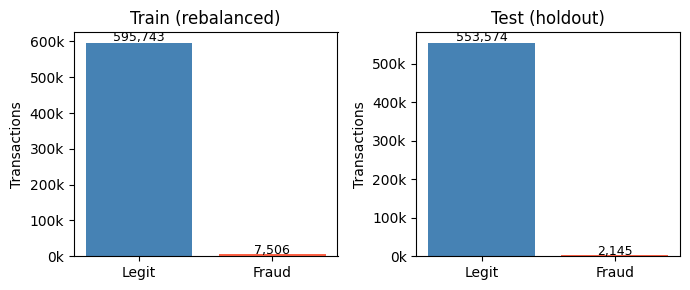

Imbalance  train: 79.4x
Imbalance  test : 258.1x


In [ ]:
# class balance train/test
fig, axes = plt.subplots(1, 2, figsize=(7, 3))
for ax, df, title in zip(axes, [train, test], ['Train (rebalanced)', 'Test (holdout)']):
    counts = df['is_fraud'].value_counts()
    ax.bar(['Legit', 'Fraud'], counts.values, color=['steelblue', 'tomato'])
    ax.set_title(title)
    ax.set_ylabel('Transactions')
    for i, v in enumerate(counts.values):
        ax.text(i, v * 1.01, f'{v:,}', ha='center', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
plt.tight_layout()
plt.show()

print(f'Imbalance  train: {(train["is_fraud"]==0).sum() / (train["is_fraud"]==1).sum():.1f}x')
print(f'Imbalance  test : {(test["is_fraud"]==0).sum() / (test["is_fraud"]==1).sum():.1f}x')

In [ ]:
# 2. FEATURE PREP

In [10]:
# columns to drop (identifiers, raw dates, target)
DROP_COLS = ['trans_num', 'cc_num', 'merchant', 'is_fraud', 'unix_time', 'cust_lat', 'cust_long', 'merch_lat', 'merch_long']
CAT_COLS = ['IP_Country', 'MerchantCategory', 'MerchantCountry', 'CarrierType', 'IdentityVerificationStatus']

# label-encoding
from sklearn.preprocessing import LabelEncoder
encoders = {}
for col in CAT_COLS:
    if col in train.columns:
        le = LabelEncoder()
        train[col] = le.fit_transform(train[col].astype(str))
        test[col]  = le.transform(test[col].astype(str).map(lambda x: x if x in le.classes_ else le.classes_[0]))
        encoders[col] = le

feature_cols = [c for c in train.columns if c not in DROP_COLS and train[c].dtype in [np.float64, np.int64, np.float32, np.int32, np.int8]]

print(f'{len(feature_cols)} feature columns:')
print(feature_cols[:10], '...')

112 feature columns:
['TransactionHour', 'DayOfWeek', 'IsWeekend', 'IsNightTxn', 'amt', 'AmountZScore', 'AmountPercentileRank', 'IsHighAmount', 'AmtToMaxRatio', 'TxnCount_1h'] ...


In [11]:
# null check
null_counts = train[feature_cols].isnull().sum()
print(f'Features with nulls: {(null_counts > 0).sum()}')
null_counts[null_counts > 0].sort_values(ascending=False).head(10)

Features with nulls: 3


DaysSincePasswordChangeBucket    512894
DaysSincePasswordChange           88145
TimeSinceLastTxnSec                 502
dtype: int64

In [12]:
# fill nulls
X_train_full = train[feature_cols].fillna(-999).values
y_train_full = train['is_fraud'].values
X_test = test[feature_cols].fillna(-999).values
y_test = test['is_fraud'].values

# 80/20 internal split for early stopping
X_tr, X_val, y_tr, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=SEED, stratify=y_train_full)
print(f'Train: {len(X_tr):,};  Val: {len(X_val):,};  Test: {len(X_test):,}')

Train: 482,599;  Val: 120,650;  Test: 555,719


In [ ]:
# 3. TRAIN (LIGHTGBM)

In [16]:
n_neg = (y_tr == 0).sum()
n_pos = (y_tr == 1).sum()
spw = round(n_neg / n_pos, 2)
print(f'scale_pos_weight = {spw} (neg={n_neg:,} pos={n_pos:,})')

scale_pos_weight = 79.37 (neg=476,594 pos=6,005)


In [17]:
params = dict(
    objective = 'binary',
    metric = ['binary_logloss', 'auc'],
    boosting_type = 'gbdt',
    n_estimators = 2000,
    learning_rate = 0.05,
    num_leaves = 63,
    max_depth = 7,
    min_child_samples = 100,
    feature_fraction = 0.7,
    bagging_fraction = 0.7,
    bagging_freq = 5,
    reg_alpha = 0.5,
    reg_lambda = 2.0,
    min_split_gain = 0.01,
    scale_pos_weight = spw,
    verbose = -1,
    n_jobs = -1,
    random_state = SEED,
)

model = lgb.LGBMClassifier(**params)
model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(100),
    ],
)

print(f'\nTop iteration: {model.best_iteration_}')

[100]	valid_0's binary_logloss: 0.00451217	valid_0's auc: 0.999952
[200]	valid_0's binary_logloss: 0.00173718	valid_0's auc: 0.999978
[300]	valid_0's binary_logloss: 0.00124334	valid_0's auc: 0.999982
[400]	valid_0's binary_logloss: 0.00111119	valid_0's auc: 0.999984

Top iteration: 382


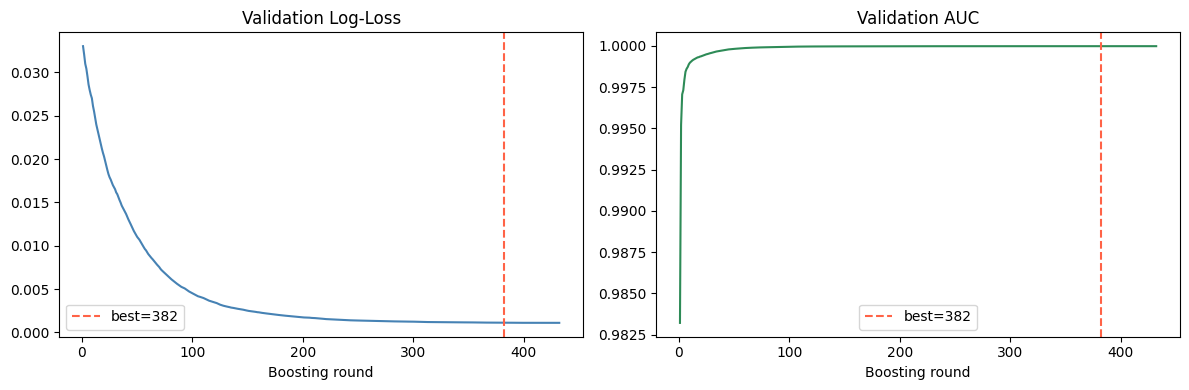

In [18]:
# training curve - logloss over boosting rounds
results = model.evals_result_
rounds  = range(1, len(results['valid_0']['binary_logloss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(rounds, results['valid_0']['binary_logloss'], color='steelblue')
axes[0].axvline(model.best_iteration_, color='tomato', linestyle='--', label=f'best={model.best_iteration_}')
axes[0].set_title('Validation Log-Loss')
axes[0].set_xlabel('Boosting round')
axes[0].legend()

axes[1].plot(rounds, results['valid_0']['auc'], color='seagreen')
axes[1].axvline(model.best_iteration_, color='tomato', linestyle='--', label=f'best={model.best_iteration_}')
axes[1].set_title('Validation AUC')
axes[1].set_xlabel('Boosting round')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# 4. THRESHOLD

In [19]:
y_val_prob = model.predict_proba(X_val)[:, 1]

prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_val, y_val_prob)
f1_arr = 2 * prec_arr * rec_arr / np.where(prec_arr + rec_arr == 0, 1, prec_arr + rec_arr)

best_idx  = f1_arr[:-1].argmax()
threshold = float(thresh_arr[best_idx])

print(f'Optimal threshold: {threshold:.4f}')
print(f'Precision: {prec_arr[best_idx]:.4f}')
print(f'Recall: {rec_arr[best_idx]:.4f}')
print(f'F1: {f1_arr[best_idx]:.4f}')

Optimal threshold: 0.8895
Precision: 0.9933
Recall: 0.9880
F1: 0.9906


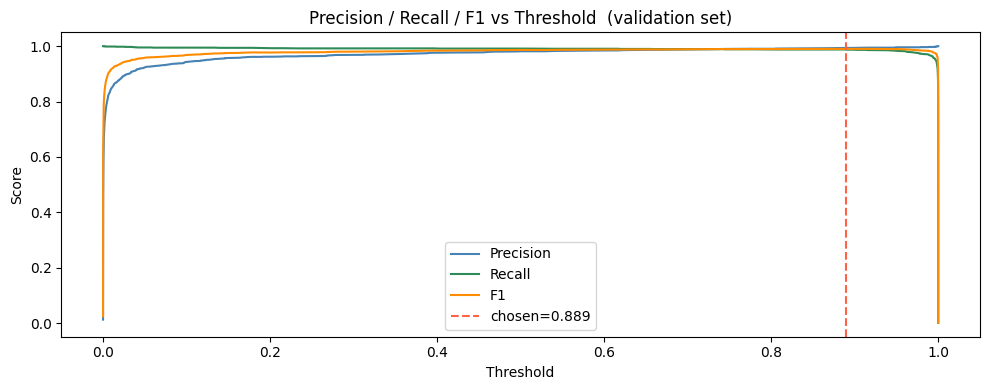

In [20]:
# P/R/F1 vs threshold
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresh_arr, prec_arr[:-1], label='Precision', color='steelblue')
ax.plot(thresh_arr, rec_arr[:-1],  label='Recall',    color='seagreen')
ax.plot(thresh_arr, f1_arr[:-1],   label='F1',        color='darkorange')
ax.axvline(threshold, color='tomato', linestyle='--', label=f'chosen={threshold:.3f}')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs Threshold  (validation set)')
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# 5. HOLDOUT EVALUATION

In [23]:
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= threshold).astype(int)

roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()


print('HOLDOUT EVALUATION')
print('-' * 45)
print(f'Threshold: {threshold:.4f}')
print(f'ROC-AUC: {roc_auc:.4f}')
print(f'PR-AUC : {pr_auc:.4f}')
print(f'Precision : {prec:.4f}')
print(f'Recall : {rec:.4f}')
print(f'F1 : {f1:.4f}')
print()
print(f'TP (fraud caught): {tp:>2,} / {tp+fn:,} ({tp/(tp+fn):.1%})')
print(f'FP (legit blocked): {fp:>2,} / {tn+fp:,} ({fp/(tn+fp):.3%})')
print(f'FN (fraud missed): {fn:>2,}')
print(f'TN (legit approved): {tn:>2,}')

HOLDOUT EVALUATION
---------------------------------------------
Threshold: 0.8895
ROC-AUC: 1.0000
PR-AUC : 0.9958
Precision : 0.9827
Recall : 0.9781
F1 : 0.9804

TP (fraud caught): 2,098 / 2,145 (97.8%)
FP (legit blocked): 37 / 553,574 (0.007%)
FN (fraud missed): 47
TN (legit approved): 553,537


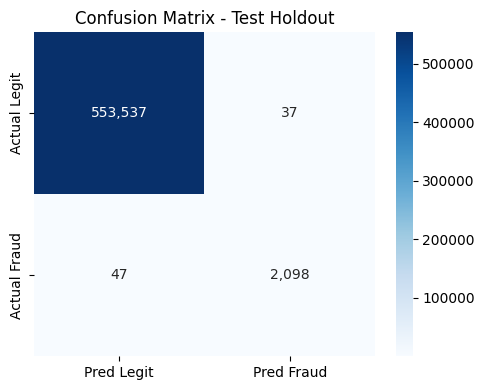

In [24]:
# confusion matrix heatmap
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt=',', cmap='Blues', ax=ax,
    xticklabels=['Pred Legit', 'Pred Fraud'],
    yticklabels=['Actual Legit', 'Actual Fraud'],
)
ax.set_title('Confusion Matrix - Test Holdout')
plt.tight_layout()
plt.show()

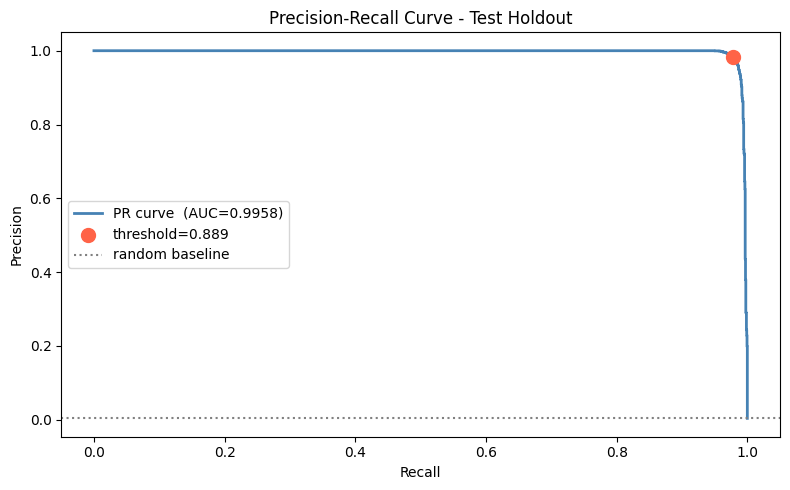

In [25]:
# PR curve
p_arr, r_arr, t_arr = precision_recall_curve(y_test, y_prob)
thresh_f1 = 2 * p_arr * r_arr / np.where(p_arr + r_arr == 0, 1, p_arr + r_arr)
marker_idx = np.argmin(np.abs(t_arr - threshold))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(r_arr, p_arr, color='steelblue', lw=2, label=f'PR curve  (AUC={pr_auc:.4f})')
ax.scatter(r_arr[marker_idx], p_arr[marker_idx],
           s=100, zorder=5, color='tomato', label=f'threshold={threshold:.3f}')
ax.axhline(y_test.mean(), color='grey', linestyle=':', label='random baseline')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve - Test Holdout')
ax.legend()

plt.tight_layout()
plt.show()

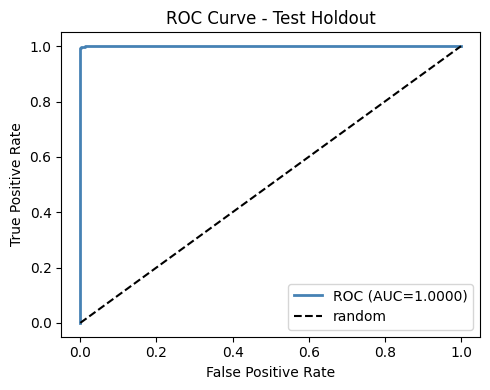

In [27]:
# ROC curve
fpr_arr, tpr_arr, _ = roc_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr_arr, tpr_arr, color='steelblue', lw=2, label=f'ROC (AUC={roc_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', label='random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - Test Holdout')
ax.legend()

plt.tight_layout()
plt.show()

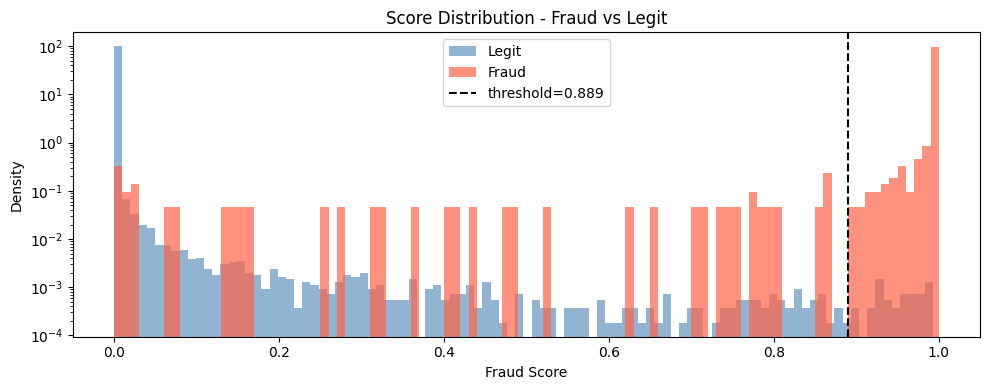

In [28]:
# fraud score distribution - fraud vs legit
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(y_prob[y_test == 0], bins=100, alpha=0.6, color='steelblue', label='Legit',  density=True)
ax.hist(y_prob[y_test == 1], bins=100, alpha=0.7, color='tomato',    label='Fraud',  density=True)
ax.axvline(threshold, color='black', linestyle='--', label=f'threshold={threshold:.3f}')
ax.set_xlabel('Fraud Score')
ax.set_ylabel('Density')
ax.set_title('Score Distribution - Fraud vs Legit')
ax.legend()
ax.set_yscale('log')

plt.tight_layout()
plt.show()

In [ ]:
# 6. DECISION BINS

In [29]:
APPROVE_THRESH = threshold * 0.6   
# below this^^ = approve
# between APPROVE_THRESH and threshold = review
# above threshold = decline

decisions = np.where(y_prob >= threshold, 'decline', np.where(y_prob >= APPROVE_THRESH, 'review', 'approve'))

scored = pd.DataFrame({'is_fraud': y_test, 'score': y_prob, 'decision': decisions})

summary = (scored.groupby('decision')
                 .agg(count=('is_fraud','count'), fraud_count=('is_fraud','sum'))
                 .assign(fraud_rate=lambda d: d['fraud_count']/d['count'])
                 .loc[['approve','review','decline']])

summary['pct_of_total'] = summary['count'] / len(scored)

print(summary.to_string())

           count  fraud_count  fraud_rate  pct_of_total
decision                                               
approve   553495           29    0.000052      0.995998
review        89           18    0.202247      0.000160
decline     2135         2098    0.982670      0.003842


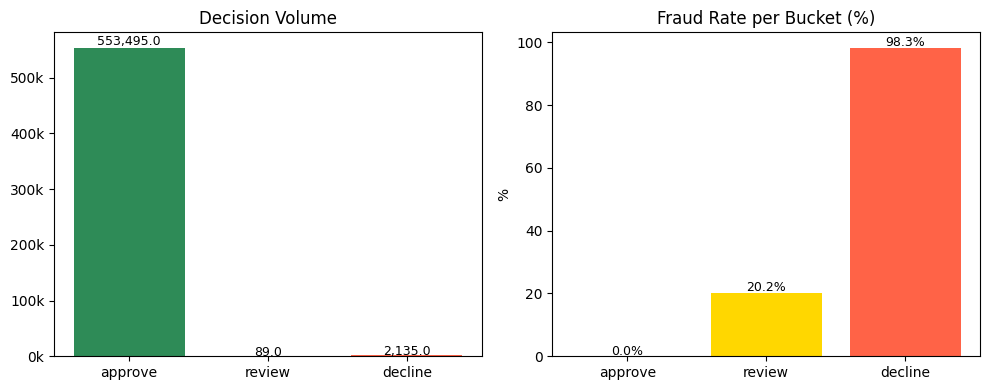

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# volume
colors = ['seagreen', 'gold', 'tomato']
axes[0].bar(summary.index, summary['count'], color=colors)
axes[0].set_title('Decision Volume')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
for i, (idx, row) in enumerate(summary.iterrows()):
    axes[0].text(i, row['count'] * 1.01, f'{row["count"]:,}', ha='center', fontsize=9)

# fraud rate per bucket
axes[1].bar(summary.index, summary['fraud_rate'] * 100, color=colors)
axes[1].set_title('Fraud Rate per Bucket (%)')
axes[1].set_ylabel('%')
for i, (idx, row) in enumerate(summary.iterrows()):
    axes[1].text(i, row['fraud_rate'] * 100 + 0.5, f'{row["fraud_rate"]:.1%}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# 7. FEATURE IMPORTANCE

In [35]:
gain = model.booster_.feature_importance(importance_type='gain')
split = model.booster_.feature_importance(importance_type='split')

imp_df = pd.DataFrame({'feature': feature_cols, 'gain': gain, 'split': split})
imp_df['gain_pct'] = imp_df['gain'] / imp_df['gain'].sum() * 100
imp_df['split_pct'] = imp_df['split'] / imp_df['split'].sum() * 100
imp_df = imp_df.sort_values('gain', ascending=False)

imp_df[['feature', 'gain_pct', 'split_pct']].head(20)

,feature,gain_pct,split_pct
16,AvgTxnAmtLast24h,58.921237,4.652997
56,BotLikelihoodScore,18.576379,6.272345
4,amt,6.643394,3.117771
58,SessionDurationSec,4.947877,2.723449
57,CheckoutTimeSec,2.020195,4.179811
109,IsNewDevice_x_IPRisk,1.124689,0.993691
97,MerchantAmountZScore,0.988684,5.525762
60,InteractionComplexityScore,0.956563,4.416404
59,PagesViewed,0.911977,2.576236
67,MerchantFraudRate_Train,0.883716,1.898002


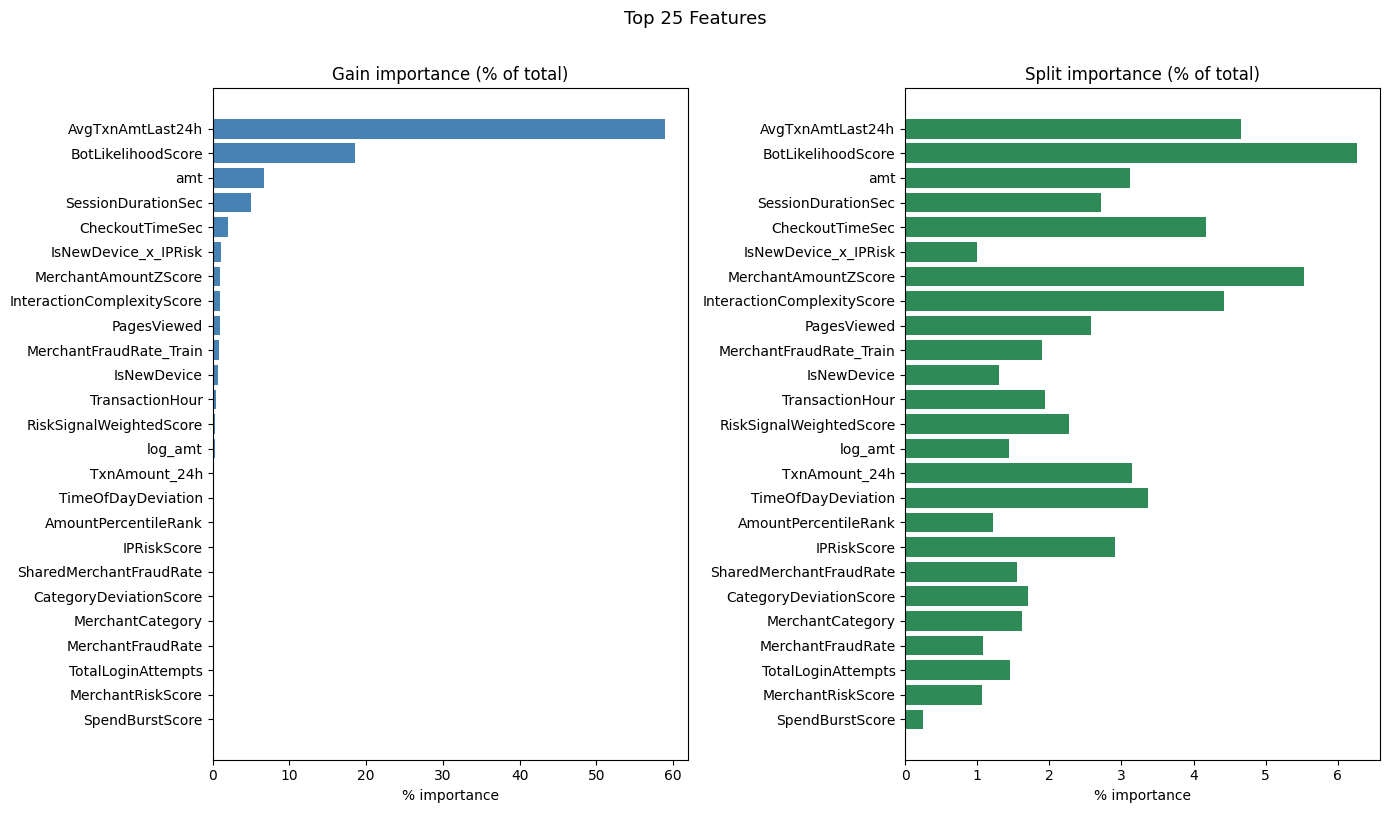

In [36]:
# top feats
top = imp_df.head(25)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
for ax, col, title, color in [
    (axes[0], 'gain_pct',  'Gain importance (% of total)',  'steelblue'),
    (axes[1], 'split_pct', 'Split importance (% of total)', 'seagreen'),
]:
    ax.barh(top['feature'][::-1], top[col][::-1], color=color)
    ax.set_xlabel('% importance')
    ax.set_title(title)

plt.suptitle('Top 25 Features', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [37]:
# features contributing bottom 10% of gain - (vars to drop)
low_gain = imp_df[imp_df['gain'] == 0]
print(f'Zero-gain features: {len(low_gain)}')
print(low_gain['feature'].tolist())

Zero-gain features: 13
['IsHighAmount', 'IsDisposableEmail', 'IsFirstTxn', 'SuspiciousGeoSpeed', 'Rule_HighVelocity', 'ImpossibleTravelFlag', 'Rule_VOIPPhone', 'Rule_DisposableEmail', 'LinkedFraudAccounts', 'NullPwdChange', 'DeviceClusterSize', 'DaysSincePasswordChangeBucket', 'HasPasswordChange']


In [ ]:
# 8. SHAP

In [38]:
# 2k sample (faster)
sample_idx = rng.choice(len(X_test), size=2000, replace=False)
X_sample = X_test[sample_idx]
y_sample = y_test[sample_idx]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values
print(f'SHAP values shape: {sv.shape}')

SHAP values shape: (2000, 112)


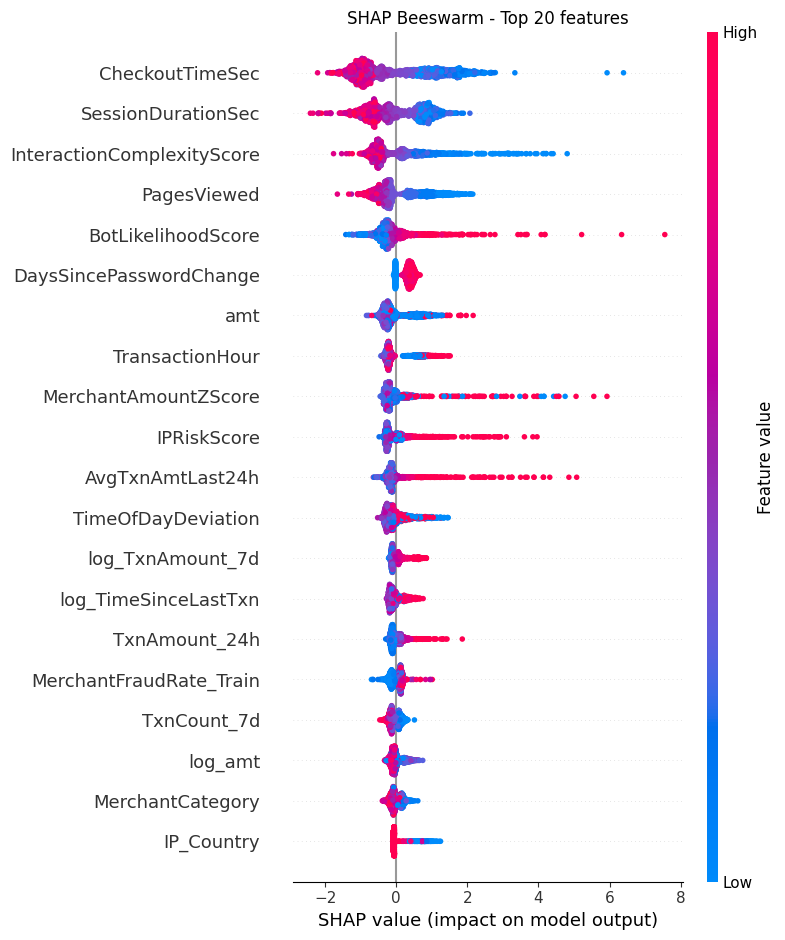

In [39]:
shap.summary_plot(sv, X_sample, feature_names=feature_cols, max_display=20,
                  show=False, plot_type='dot')
plt.title('SHAP Beeswarm - Top 20 features')
plt.tight_layout()
plt.show()

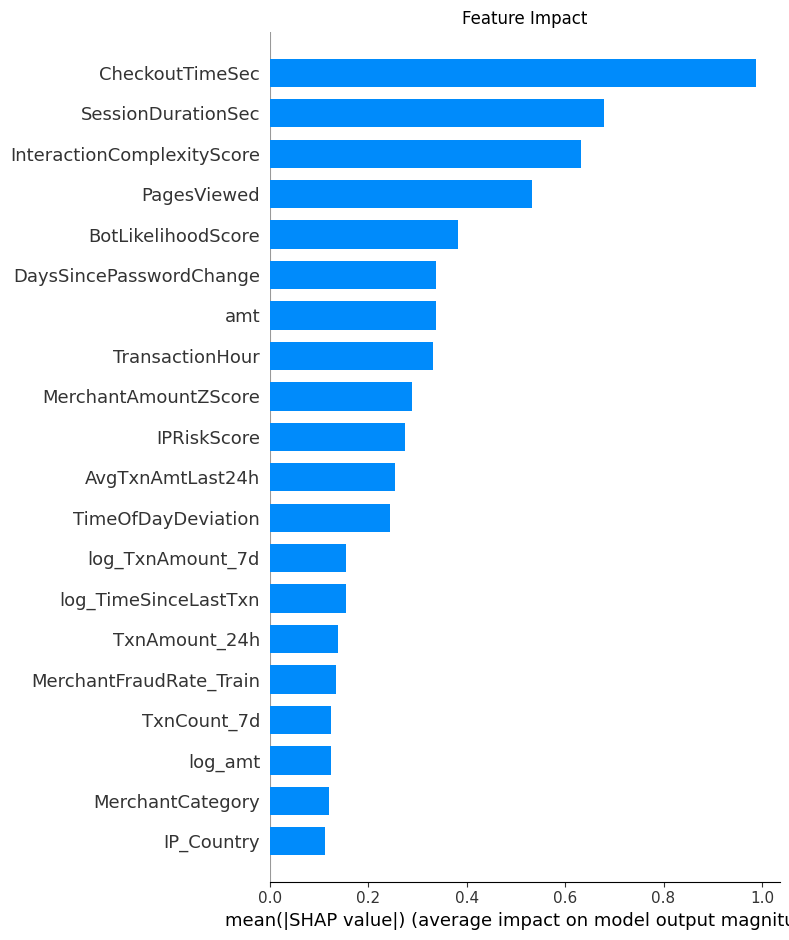

In [ ]:
# mean SHAP val barchart
shap.summary_plot(sv, X_sample, feature_names=feature_cols, max_display=20, show=False, plot_type='bar')
plt.title('Feature Impact')

plt.tight_layout()
plt.show()

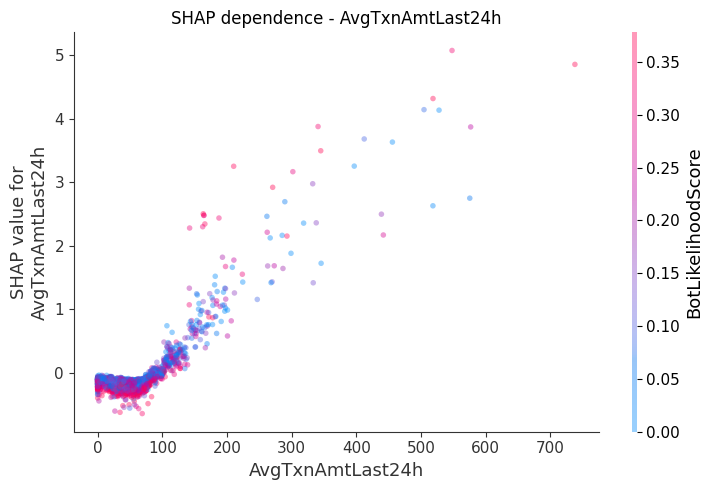

In [41]:
# SHAP dependence plot (top feat)
top_feat = imp_df.iloc[0]['feature']
top_idx = feature_cols.index(top_feat)

shap.dependence_plot(top_idx, sv, X_sample, feature_names=feature_cols, show=False, alpha=0.4)
plt.title(f'SHAP dependence - {top_feat}') #
plt.tight_layout()
plt.show()

In [ ]:
# 9. FALSE FLAGS

In [42]:
test_scored = test.copy()
test_scored['score']    = y_prob
test_scored['decision'] = decisions
test_scored['correct']  = (y_pred == y_test).astype(int)

fp_rows = test_scored[(test_scored['is_fraud'] == 0) & (test_scored['decision'] == 'decline')]
fn_rows = test_scored[(test_scored['is_fraud'] == 1) & (test_scored['decision'] == 'approve')]

print(f'False positives (legit blocked): {len(fp_rows):,}')
print(f'False negatives (fraud missed): {len(fn_rows):,}')

False positives (legit blocked): 37
False negatives (fraud missed): 29


In [43]:
# FP quick look
fp_cols = [
    'score', 
    'amt', 
    'BotLikelihoodScore', 
    'IPRiskScore',
    'CheckoutTimeSec', 
    'SessionDurationSec', 
    'IsNewDevice', 
    'IsVPN', 
    'RiskSignalCount'
    ]

fp_cols_present = [c for c in fp_cols if c in fp_rows.columns]

print('False Positives (sample):')
fp_rows[fp_cols_present].head(10)

False Positives (sample):


,score,amt,BotLikelihoodScore,IPRiskScore,CheckoutTimeSec,SessionDurationSec,IsNewDevice,IsVPN,RiskSignalCount
6598,0.975320,9.75,0.230,55.2,12,128,0,0.0,2
15323,0.936073,11.36,0.462,43.9,42,208,0,0.0,1
22635,0.972742,400.16,0.318,30.7,50,137,0,1.0,5
22656,0.927278,810.89,0.417,92.5,29,196,0,0.0,3
31855,0.892864,384.45,0.263,61.0,44,258,0,0.0,0
54296,0.935010,303.91,0.240,73.0,10,97,0,0.0,2
59014,0.964476,9.25,0.547,27.9,69,290,0,1.0,2
61297,0.983925,22.71,0.620,30.4,32,20,0,0.0,1
82140,0.978019,42.57,0.284,73.3,10,120,0,0.0,2
92712,0.975903,2239.64,0.354,29.8,65,222,0,0.0,1


In [44]:
# FN quick look
fn_cols = [
    'score', 
    'amt', 
    'BotLikelihoodScore', 
    'IPRiskScore',
    'CheckoutTimeSec', 
    'SessionDurationSec', 
    'IsNewDevice', 
    'IsVPN', 
    'RiskSignalCount'
    ]

fn_cols_present = [c for c in fn_cols if c in fn_rows.columns]

print('False Negatives (sample):')
fn_rows[fn_cols_present].head(10)

False Negatives (sample):


,score,amt,BotLikelihoodScore,IPRiskScore,CheckoutTimeSec,SessionDurationSec,IsNewDevice,IsVPN,RiskSignalCount
30849,0.000256,959.59,0.197,17.8,56,245,0,1.0,2
37324,0.481142,50.59,0.314,0.0,1,29,1,0.0,1
72296,0.401361,257.51,0.271,83.9,98,143,0,0.0,2
83180,0.029219,8.41,0.371,63.0,7,268,0,0.0,4
83875,0.061735,8.49,0.222,69.0,34,66,0,0.0,1
141626,0.141332,714.17,0.186,59.2,38,68,0,0.0,2
187664,0.416520,106.11,0.461,59.7,36,36,0,0.0,2
195892,0.026555,19.02,0.383,0.0,26,39,0,0.0,0
199266,0.317701,321.06,0.244,37.5,46,144,0,0.0,1
203349,0.000174,8.96,0.150,68.0,68,203,0,0.0,1


In [ ]:
# compare FP/FN/TP key feature means
tp_rows = test_scored[(test_scored['is_fraud'] == 1) & (test_scored['decision'] == 'decline')]

compare_cols = ['score', 'amt', 'BotLikelihoodScore', 'CheckoutTimeSec', 'SessionDurationSec', 'IPRiskScore', 'RiskSignalCount']
compare_cols = [c for c in compare_cols if c in test_scored.columns]

comparison = pd.DataFrame({
    'FP (legit blocked)': fp_rows[compare_cols].mean(),
    'FN (fraud missed)' : fn_rows[compare_cols].mean(),
    'TP (fraud caught)' : tp_rows[compare_cols].mean(),
})
comparison.round(3)

,FP (legit blocked),FN (fraud missed),TP (fraud caught)
score,0.951,0.177,0.999
amt,419.638,231.099,535.871
BotLikelihoodScore,0.385,0.276,0.552
CheckoutTimeSec,45.703,39.241,35.673
SessionDurationSec,168.622,138.586,126.838
IPRiskScore,44.476,40.279,52.619
RiskSignalCount,2.270,1.862,2.534


In [ ]:
# 10. QUICK SUMMARY

In [47]:
fraud_in_test = y_test.sum()

print('MODEL SUMMARY')
print('-' * 50)
print(f'Algorithm: LightGBM')
print(f'Features: {len(feature_cols)}')
print(f'Best iteration: {model.best_iteration_}')
print(f'Threshold: {threshold:.4f}')
print()
print(f'ROC-AUC: {roc_auc:.4f}')
print(f'PR-AUC: {pr_auc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall: {rec:.4f}')
print(f'F1: {f1:.4f}')
print()
print(f'Fraud caught: {tp:,} / {fraud_in_test:,} ({tp/fraud_in_test:.1%})')
print(f'Legit blocked: {fp:,} / {tn+fp:,} ({fp/(tn+fp):.3%})')
print(f'Review queue: {(decisions=="review").sum():,} txns')
print(f'Top feature: {imp_df.iloc[0]["feature"]} ({imp_df.iloc[0]["gain_pct"]:.1f}% gain)')

MODEL SUMMARY
--------------------------------------------------
Algorithm: LightGBM
Features: 112
Best iteration: 382
Threshold: 0.8895

ROC-AUC: 1.0000
PR-AUC: 0.9958
Precision: 0.9827
Recall: 0.9781
F1: 0.9804

Fraud caught: 2,098 / 2,145 (97.8%)
Legit blocked: 37 / 553,574 (0.007%)
Review queue: 89 txns
Top feature: AvgTxnAmtLast24h (58.9% gain)
